In [1]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "ball_beam_matplotlib"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "figure.figsize": (10.5, 6.6),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "lines.linewidth": 1.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [2]:
LOG_ROOT = Path("../telemetry_logs")
if not LOG_ROOT.exists():
    LOG_ROOT = Path("telemetry_logs")

REQUIRED_COLUMNS = [
    "t_ms",
    "mode",
    "driver",
    "d_valid",
    "d_raw",
    "d_filt",
    "setp",
    "x",
    "x_hat",
    "v_hat",
    "xi",
    "theta_cmd",
    "theta_rel_meas",
]

POSITION_YLIM = (5.0, 14.0)
ERROR_YLIM = (-3.0, 3.0)
ANGLE_YLIM = (-4.2, 4.2)

# Measurement / presentation assumptions
SENSOR_UNCERTAINTY_CM = 1.0
BALL_DIAMETER_CM = 4.0

SETTLE_IGNORE_S = 3.0
PLOT_LPF_TAU_S = 0.35

DISTURBANCE_THRESHOLD_CM = 1.0
DISTURBANCE_IGNORE_S = 3.0
DISTURBANCE_SUSTAINED_SAMPLES = 3

SETPOINT_CHANGE_EPS_CM = 0.05
EXPECTED_STAIRCASE_CM = np.array([12.50, 10.00, 7.50])

POSITION_COLOR = "#1f77b4"
SETPOINT_COLOR = "#222222"
COMMAND_COLOR = "#c23b22"
MEASURED_ANGLE_COLOR = "#2a7f62"
RAW_SENSOR_COLOR = "#888888"
UNCERTAINTY_COLOR = "#cccccc"

In [3]:
if "LOG_ROOT" not in globals():
    LOG_ROOT = Path("../telemetry_logs")
    if not LOG_ROOT.exists():
        LOG_ROOT = Path("telemetry_logs")

if "REQUIRED_COLUMNS" not in globals():
    REQUIRED_COLUMNS = [
        "t_ms",
        "mode",
        "driver",
        "d_valid",
        "d_raw",
        "d_filt",
        "setp",
        "x",
        "x_hat",
        "v_hat",
        "xi",
        "theta_cmd",
        "theta_rel_meas",
    ]


def has_required_columns(csv_path: Path) -> bool:
    if not csv_path.is_file() or csv_path.stat().st_size == 0:
        return False

    try:
        columns = pd.read_csv(csv_path, nrows=0).columns.str.strip()
    except Exception:
        return False

    return set(REQUIRED_COLUMNS).issubset(set(columns))


def latest_telemetry_csv(log_root: Path) -> Path:
    candidates = [
        csv_path
        for csv_path in log_root.glob("*/telemetry.csv")
        if has_required_columns(csv_path)
    ]

    if not candidates:
        raise FileNotFoundError(f"No valid telemetry.csv found under {log_root.resolve()}")

    return max(
        candidates,
        key=lambda path: (path.parent.stat().st_mtime, path.stat().st_mtime),
    )


csv_path = latest_telemetry_csv(LOG_ROOT)
run_dir = csv_path.parent
raw = pd.read_csv(csv_path)
raw.columns = raw.columns.str.strip()

print(f"Selected run: {run_dir}")
print(f"Telemetry CSV: {csv_path}")

meta_path = run_dir / "session_meta.json"
if meta_path.exists():
    metadata = json.loads(meta_path.read_text(encoding="utf-8"))
    print(f"Started at: {metadata.get('started_at', 'unknown')}")
    print(f"Port: {metadata.get('port', 'unknown')} @ {metadata.get('baud', 'unknown')}")

print(f"Rows loaded: {len(raw)}")

Selected run: ../telemetry_logs/20260429_162455
Telemetry CSV: ../telemetry_logs/20260429_162455/telemetry.csv
Started at: 2026-04-29T16:24:55
Port: /dev/cu.usbserial-A10N20X1 @ 115200
Rows loaded: 1376


In [4]:
def first_order_lpf_by_time(t_s, y, tau_s):
    """
    Causal first-order low-pass filter.

    y_f[k] = y_f[k-1] + alpha * (y[k] - y_f[k])
    alpha = 1 - exp(-dt / tau)

    This is used only for plotting noisy position traces.
    """
    t = np.asarray(t_s, dtype=float)
    values = np.asarray(y, dtype=float)

    if len(values) == 0:
        return values

    filtered = np.empty_like(values, dtype=float)
    filtered[0] = values[0]

    for index in range(1, len(values)):
        dt = max(t[index] - t[index - 1], 0.0)
        alpha = 1.0 - np.exp(-dt / tau_s) if tau_s > 0 else 1.0

        if np.isfinite(values[index]):
            filtered[index] = filtered[index - 1] + alpha * (
                values[index] - filtered[index - 1]
            )
        else:
            filtered[index] = filtered[index - 1]

    return filtered


def add_plot_filter_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Adds report-quality filtered signals.

    Main plotted position error is based on d_filt - setp, not x_hat.
    The filter is reset at each setpoint segment to avoid smearing across
    intentional setpoint changes.
    """
    result = frame.copy()

    result["err_ir"] = result["d_filt"] - result["setp"]
    result["pos_ir"] = result["d_filt"]

    result["err_ir_lpf"] = np.nan

    for _, segment in result.groupby("segment_id"):
        index = segment.index
        result.loc[index, "err_ir_lpf"] = first_order_lpf_by_time(
            segment["t_s"],
            segment["err_ir"],
            PLOT_LPF_TAU_S,
        )

    result["pos_ir_lpf"] = result["setp"] + result["err_ir_lpf"]

    return result


def prepare_telemetry(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"Missing required telemetry columns: {missing}")

    data = frame.copy()

    numeric_columns = [
        "t_ms",
        "mode",
        "driver",
        "d_valid",
        "d_raw",
        "d_filt",
        "setp",
        "x",
        "x_hat",
        "v_hat",
        "xi",
        "theta_cmd",
        "theta_rel_meas",
    ]

    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data = data.dropna(subset=["t_ms"]).sort_values("t_ms").reset_index(drop=True)

    if data.empty:
        raise ValueError("Telemetry CSV contains no usable timestamped rows")

    data["t_s"] = (data["t_ms"] - float(data["t_ms"].iloc[0])) / 1000.0
    data["valid_bool"] = data["d_valid"].fillna(0).astype(int).eq(1)

    data["closed_loop_bool"] = (
        data["mode"].fillna(-1).astype(int).eq(2)
        & data["driver"].fillna(0).astype(int).eq(1)
    )

    # Main presentation signals
    data["pos_hat"] = data["setp"] + data["x_hat"]
    data["err_hat"] = data["x_hat"]
    data["abs_err_hat"] = data["err_hat"].abs()

    closed_loop = data.loc[data["closed_loop_bool"]].copy().reset_index(drop=True)

    if closed_loop.empty:
        raise ValueError("No closed-loop M2 rows found where mode == 2 and driver == 1")

    setpoint_change = closed_loop["setp"].diff().abs().fillna(0.0) > SETPOINT_CHANGE_EPS_CM
    closed_loop["segment_id"] = setpoint_change.cumsum().astype(int)
    closed_loop = add_plot_filter_columns(closed_loop)

    return data, closed_loop


def valid_parts(frame: pd.DataFrame) -> list[pd.DataFrame]:
    valid = frame["valid_bool"].to_numpy(dtype=bool)
    parts = []
    start = None

    for index, is_valid in enumerate(valid):
        if is_valid and start is None:
            start = index
        elif not is_valid and start is not None:
            parts.append(frame.iloc[start:index])
            start = None

    if start is not None:
        parts.append(frame.iloc[start:])

    return [part for part in parts if not part.empty]


def plot_valid_line(
    ax,
    frame: pd.DataFrame,
    x_col: str,
    y_col: str,
    *,
    label: str,
    color: str,
    **kwargs,
) -> None:
    for part_index, part in enumerate(valid_parts(frame)):
        ax.plot(
            part[x_col],
            part[y_col],
            color=color,
            label=label if part_index == 0 else None,
            **kwargs,
        )


def rounded_time_limit(seconds: float) -> float:
    if seconds <= 0.0:
        return 1.0
    return float(np.ceil(seconds / 5.0) * 5.0)


def draw_position_axis(ax, frame: pd.DataFrame, title: str) -> None:
    """
    Physical-position plot using filtered IR-derived position.
    """
    ax.fill_between(
        frame["t_plot"],
        frame["setp"] - SENSOR_UNCERTAINTY_CM,
        frame["setp"] + SENSOR_UNCERTAINTY_CM,
        step="post",
        color=UNCERTAINTY_COLOR,
        alpha=0.35,
        label=f"approx. ±{SENSOR_UNCERTAINTY_CM:.1f} cm sensor uncertainty",
    )

    ax.step(
        frame["t_plot"],
        frame["setp"],
        where="post",
        color=SETPOINT_COLOR,
        linestyle="--",
        linewidth=1.6,
        label="setpoint",
    )

    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "pos_ir_lpf",
        label=f"filtered IR-derived position, LPF τ={PLOT_LPF_TAU_S:.2f}s",
        color=POSITION_COLOR,
        linewidth=2.2,
    )

    ax.set_ylim(*POSITION_YLIM)
    ax.set_ylabel("position [cm]")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)


def draw_error_axis(ax, frame: pd.DataFrame, title: str) -> None:
    """
    Main control-performance plot.

    The plotted signal is IR-derived position error after a defined
    first-order low-pass filter. Raw/less-filtered signals are shown
    separately in the diagnostic plot.
    """
    ax.axhspan(
        -SENSOR_UNCERTAINTY_CM,
        SENSOR_UNCERTAINTY_CM,
        color=UNCERTAINTY_COLOR,
        alpha=0.35,
        label=f"approx. ±{SENSOR_UNCERTAINTY_CM:.1f} cm sensor uncertainty",
    )

    ax.axhline(
        0.0,
        color=SETPOINT_COLOR,
        linestyle="--",
        linewidth=1.3,
        label="target error = 0",
    )

    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "err_ir_lpf",
        label=f"filtered IR-derived position error, LPF τ={PLOT_LPF_TAU_S:.2f}s",
        color=POSITION_COLOR,
        linewidth=2.2,
    )

    ax.set_ylim(*ERROR_YLIM)
    ax.set_ylabel("position error [cm]")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)


def draw_angle_axis(ax, frame: pd.DataFrame) -> None:
    ax.axhline(0.0, color="0.35", linewidth=0.9, alpha=0.75)

    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "theta_cmd",
        label="commanded beam angle",
        color=COMMAND_COLOR,
    )

    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "theta_rel_meas",
        label="measured beam angle",
        color=MEASURED_ANGLE_COLOR,
        alpha=0.9,
    )

    ax.set_ylim(*ANGLE_YLIM)
    ax.set_ylabel("beam angle [deg]")
    ax.set_xlabel("time [s]")
    ax.legend(loc="best", frameon=True)


def detect_disturbance(segment: pd.DataFrame) -> float | None:
    local_t = segment["t_plot"]

    # Keep disturbance detection tied to controller observer estimate.
    mask = (
        segment["valid_bool"]
        & local_t.ge(DISTURBANCE_IGNORE_S)
        & segment["err_hat"].abs().gt(DISTURBANCE_THRESHOLD_CM)
    ).to_numpy(dtype=bool)

    needed = max(1, int(DISTURBANCE_SUSTAINED_SAMPLES))

    for start in range(0, max(0, len(mask) - needed + 1)):
        if mask[start : start + needed].all():
            return float(local_t.iloc[start])

    return None


def segment_frame(closed_loop: pd.DataFrame, segment_id: int) -> pd.DataFrame:
    segment = closed_loop.loc[closed_loop["segment_id"].eq(segment_id)].copy()

    if segment.empty:
        raise ValueError(f"Missing closed-loop segment {segment_id}")

    segment["t_plot"] = segment["t_s"] - float(segment["t_s"].iloc[0])
    return segment


telemetry, closed_loop = prepare_telemetry(raw)

segment_summary = closed_loop.groupby("segment_id").agg(
    t_start_s=("t_s", "first"),
    t_end_s=("t_s", "last"),
    setpoint_cm=("setp", "first"),
    rows=("t_s", "size"),
    median_abs_error_cm=("abs_err_hat", "median"),
    p95_abs_error_cm=("abs_err_hat", lambda s: s.quantile(0.95)),
)

print(f"Closed-loop rows: {len(closed_loop)}")
print(segment_summary.to_string(float_format=lambda value: f"{value:.3f}"))

Closed-loop rows: 1332
            t_start_s  t_end_s  setpoint_cm  rows  median_abs_error_cm  p95_abs_error_cm
segment_id                                                                              
0               2.960   22.240       10.000   242                0.108             2.245
1              22.320   42.240       12.500   250                0.134             0.656
2              42.322   62.240       10.000   250                0.185             2.701
3              62.321  109.440        7.000   590                0.113             0.220


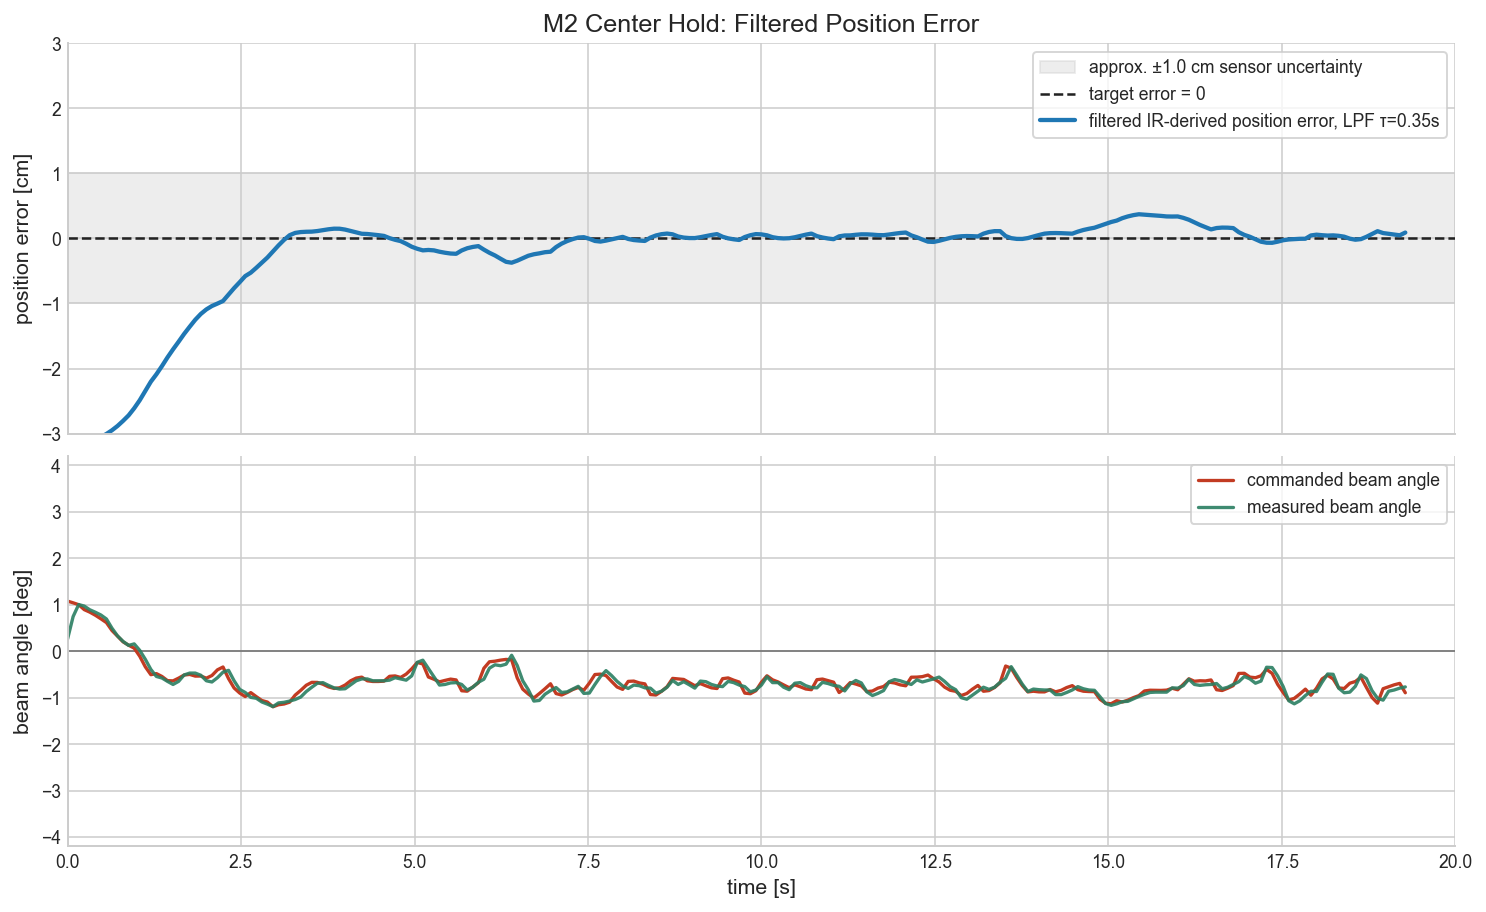

In [5]:
plt.close("all")

center = segment_frame(closed_loop, 0)
disturbance_s = detect_disturbance(center)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10.5, 6.4), constrained_layout=True)

draw_error_axis(
    axes[0],
    center,
    "M2 Center Hold: Filtered Position Error"
)
draw_angle_axis(axes[1], center)

if disturbance_s is not None:
    for axis in axes:
        axis.axvline(
            disturbance_s,
            color="0.25",
            linestyle=":",
            linewidth=1.2,
            label="detected disturbance",
        )

    for axis in axes:
        handles, labels = axis.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axis.legend(unique.values(), unique.keys(), loc="best", frameon=True)

axes[1].set_xlim(0.0, rounded_time_limit(float(center["t_plot"].iloc[-1])))

plt.show()

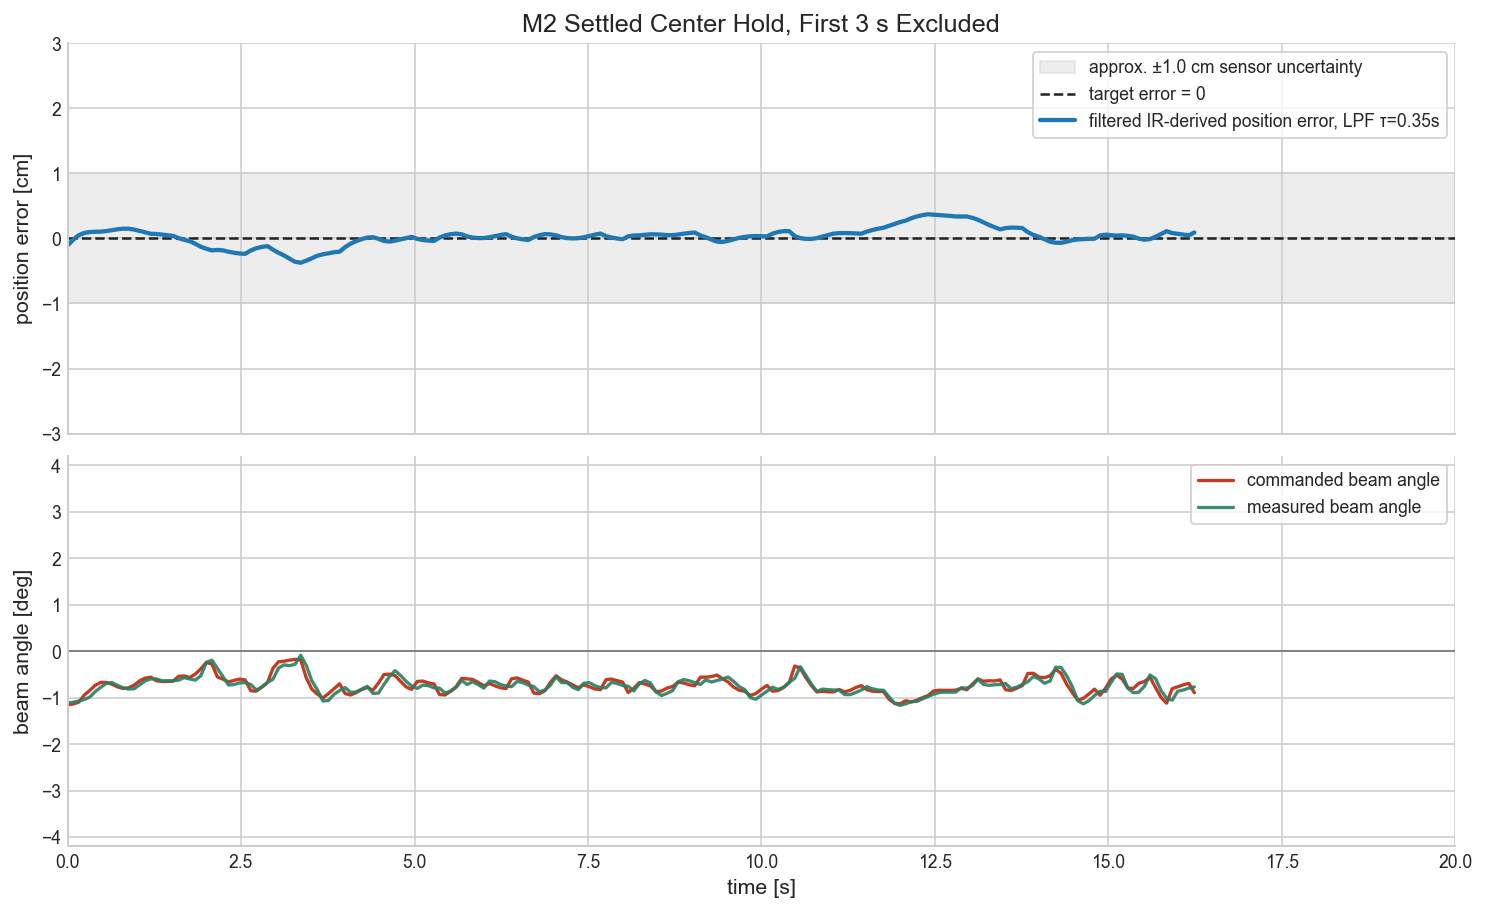

In [6]:
plt.close("all")

center_settled = center.loc[center["t_plot"].ge(SETTLE_IGNORE_S)].copy()
center_settled["t_plot"] = center_settled["t_plot"] - float(center_settled["t_plot"].iloc[0])

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10.5, 6.4), constrained_layout=True)

draw_error_axis(
    axes[0],
    center_settled,
    f"M2 Settled Center Hold, First {SETTLE_IGNORE_S:.0f} s Excluded",
)

draw_angle_axis(axes[1], center_settled)

axes[1].set_xlim(0.0, rounded_time_limit(float(center_settled["t_plot"].iloc[-1])))

plt.show()

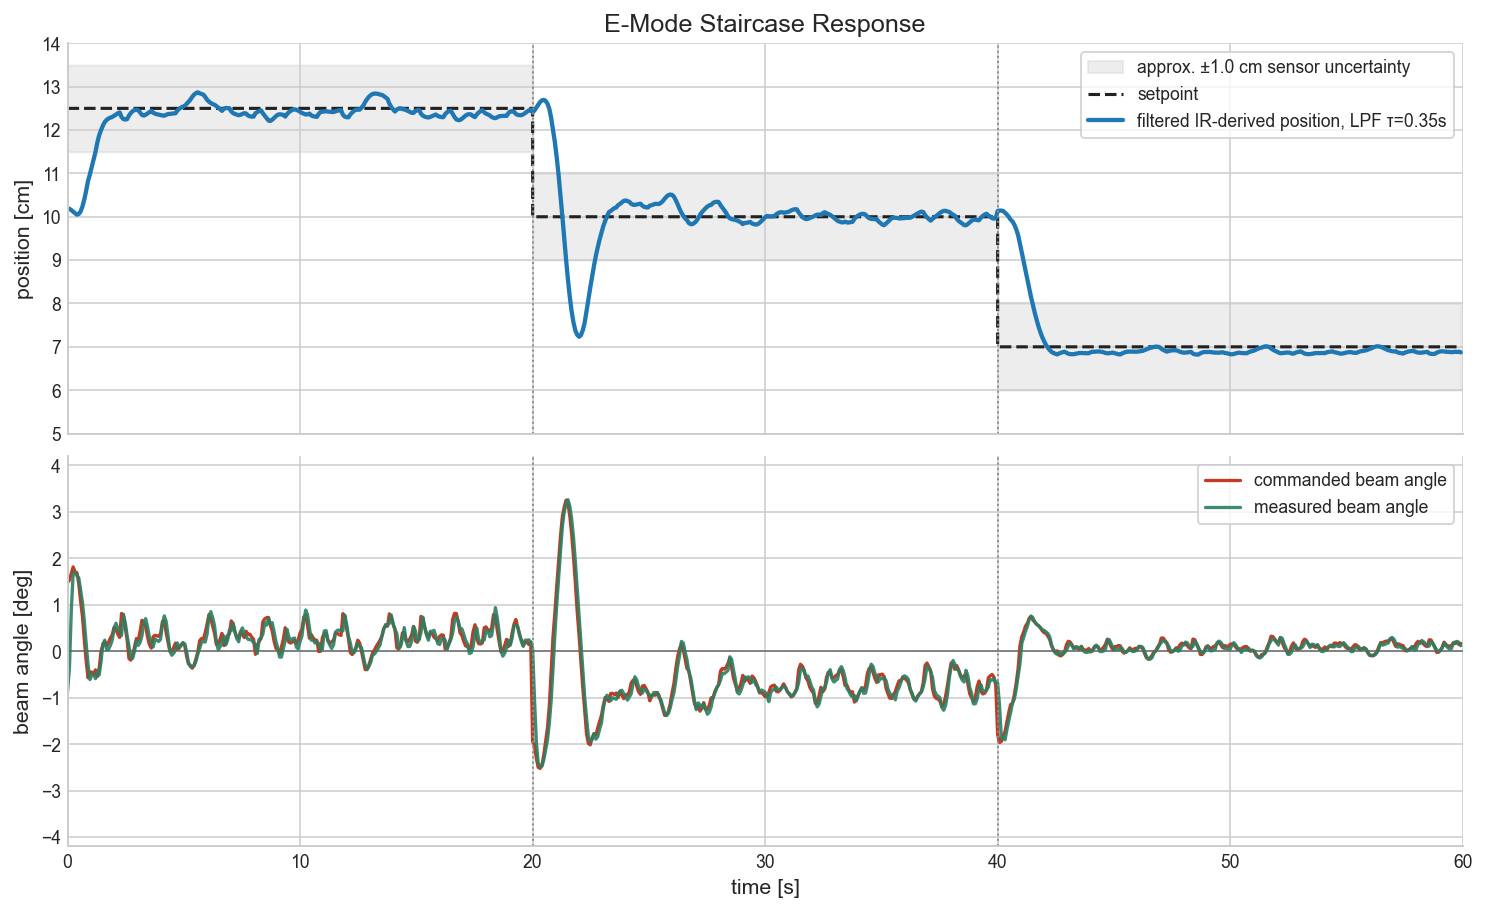

In [7]:
def find_staircase_segment_ids(closed_loop: pd.DataFrame) -> list[int]:
    segment_ids = sorted(closed_loop["segment_id"].unique().tolist())
    setpoints = {
        segment_id: float(closed_loop.loc[closed_loop["segment_id"].eq(segment_id), "setp"].iloc[0])
        for segment_id in segment_ids
    }

    for index in range(0, len(segment_ids) - len(EXPECTED_STAIRCASE_CM) + 1):
        candidate_ids = segment_ids[index : index + len(EXPECTED_STAIRCASE_CM)]
        candidate_setpoints = np.array([setpoints[segment_id] for segment_id in candidate_ids])
        if np.allclose(candidate_setpoints, EXPECTED_STAIRCASE_CM, atol=SETPOINT_CHANGE_EPS_CM):
            return candidate_ids

    if len(segment_ids) >= 4:
        return segment_ids[1:4]

    raise ValueError("Could not find the expected E-mode staircase segments")


staircase_ids = find_staircase_segment_ids(closed_loop)
staircase_segments = [closed_loop.loc[closed_loop["segment_id"].eq(segment_id)].copy() for segment_id in staircase_ids]
stage_durations = [float(segment["t_s"].iloc[-1] - segment["t_s"].iloc[0]) for segment in staircase_segments]
nominal_stage_duration_s = float(np.median(stage_durations[:2])) if len(stage_durations) >= 2 else stage_durations[-1]

trimmed_segments = []
for stage_index, segment in enumerate(staircase_segments):
    segment = segment.copy()
    segment["stage_index"] = stage_index
    segment["stage_t_s"] = segment["t_s"] - float(segment["t_s"].iloc[0])
    if stage_index == len(staircase_segments) - 1:
        segment = segment.loc[segment["stage_t_s"].le(nominal_stage_duration_s)].copy()
    trimmed_segments.append(segment)

staircase = pd.concat(trimmed_segments, ignore_index=True)
staircase_start_s = float(staircase["t_s"].iloc[0])
staircase["t_plot"] = staircase["t_s"] - staircase_start_s

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10.5, 6.4), constrained_layout=True)
draw_position_axis(axes[0], staircase, "E-Mode Staircase Response")
draw_angle_axis(axes[1], staircase)

for stage_index in range(1, len(trimmed_segments)):
    boundary_s = float(trimmed_segments[stage_index]["t_s"].iloc[0]) - staircase_start_s
    for axis in axes:
        axis.axvline(boundary_s, color="0.55", linestyle=":", linewidth=1.0)

axes[1].set_xlim(0.0, rounded_time_limit(float(staircase["t_plot"].iloc[-1])))
plt.show()

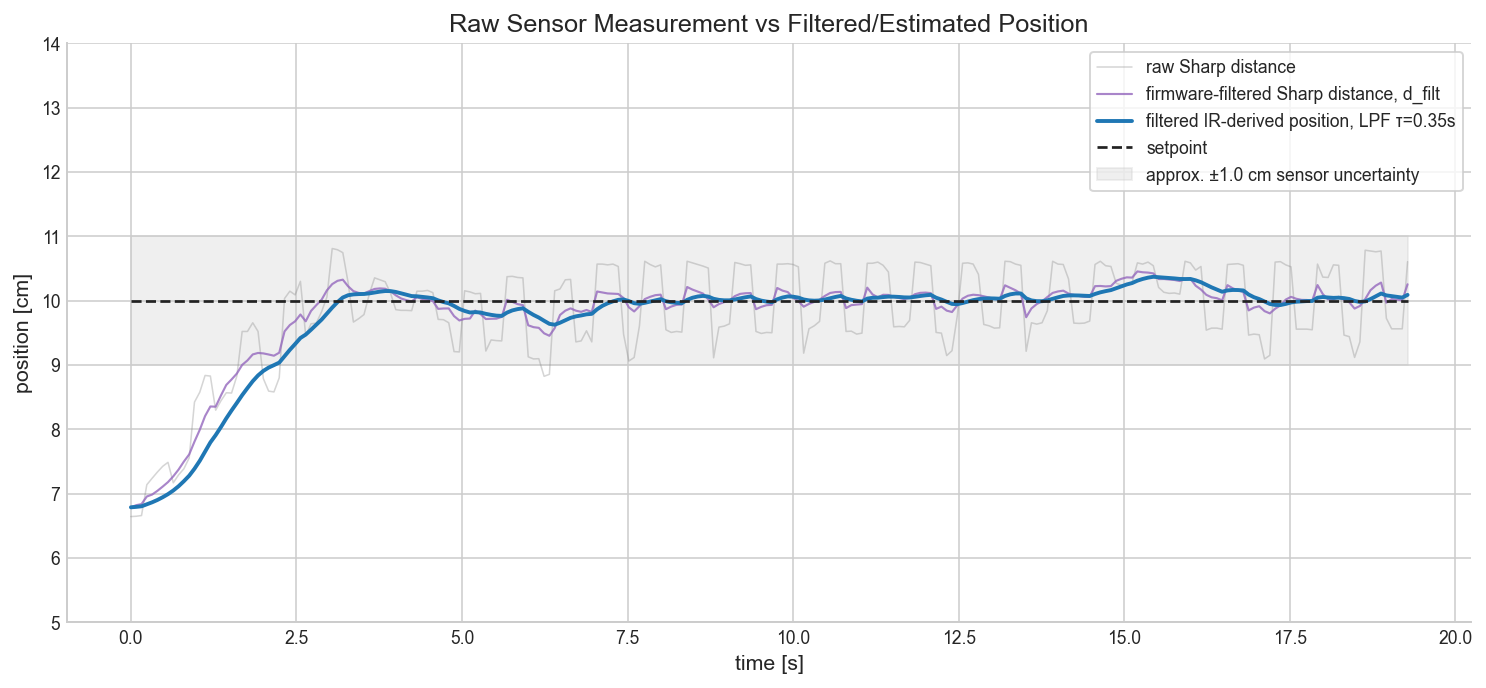

In [8]:
plt.close("all")

# Use the center-hold segment for a clear sensor-noise comparison.
diagnostic = center.copy()

fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)

plot_valid_line(
    ax,
    diagnostic,
    "t_plot",
    "d_raw",
    label="raw Sharp distance",
    color=RAW_SENSOR_COLOR,
    linewidth=0.8,
    alpha=0.35,
)

plot_valid_line(
    ax,
    diagnostic,
    "t_plot",
    "d_filt",
    label="firmware-filtered Sharp distance, d_filt",
    color="#9467bd",
    linewidth=1.1,
    alpha=0.8,
)

plot_valid_line(
    ax,
    diagnostic,
    "t_plot",
    "pos_ir_lpf",
    label=f"filtered IR-derived position, LPF τ={PLOT_LPF_TAU_S:.2f}s",
    color=POSITION_COLOR,
    linewidth=2.0,
)

ax.step(
    diagnostic["t_plot"],
    diagnostic["setp"],
    where="post",
    color=SETPOINT_COLOR,
    linestyle="--",
    linewidth=1.4,
    label="setpoint",
)

ax.fill_between(
    diagnostic["t_plot"],
    diagnostic["setp"] - SENSOR_UNCERTAINTY_CM,
    diagnostic["setp"] + SENSOR_UNCERTAINTY_CM,
    step="post",
    color=UNCERTAINTY_COLOR,
    alpha=0.30,
    label=f"approx. ±{SENSOR_UNCERTAINTY_CM:.1f} cm sensor uncertainty",
)

ax.set_title("Raw Sensor Measurement vs Filtered/Estimated Position")
ax.set_xlabel("time [s]")
ax.set_ylabel("position [cm]")
ax.set_ylim(*POSITION_YLIM)
ax.legend(loc="best", frameon=True)

plt.show()

In [9]:
def performance_metrics(frame: pd.DataFrame, name: str) -> dict:
    abs_err = frame["abs_err_hat"].dropna()

    return {
        "case": name,
        "duration_s": frame["t_s"].iloc[-1] - frame["t_s"].iloc[0],
        "rows": len(frame),
        "median_abs_error_cm": abs_err.median(),
        "p95_abs_error_cm": abs_err.quantile(0.95),
        "max_abs_error_cm": abs_err.max(),
        "percent_inside_sensor_band": 100.0 * (abs_err <= SENSOR_UNCERTAINTY_CM).mean(),
        "sensor_band_cm": SENSOR_UNCERTAINTY_CM,
        "ball_diameter_cm": BALL_DIAMETER_CM,
        "sensor_band_as_ball_diameters": SENSOR_UNCERTAINTY_CM / BALL_DIAMETER_CM,
    }


rows = []

rows.append(performance_metrics(center, "M2 center hold, full"))
rows.append(performance_metrics(center_settled, f"M2 center hold, first {SETTLE_IGNORE_S:.0f} s excluded"))

if "staircase" in globals():
    rows.append(performance_metrics(staircase, "E-mode staircase"))

metrics = pd.DataFrame(rows)

formats = {
    "duration_s": "{:.2f}",
    "median_abs_error_cm": "{:.3f}",
    "p95_abs_error_cm": "{:.3f}",
    "max_abs_error_cm": "{:.3f}",
    "percent_inside_sensor_band": "{:.1f}%",
    "sensor_band_cm": "{:.2f}",
    "ball_diameter_cm": "{:.2f}",
    "sensor_band_as_ball_diameters": "{:.2f}",
}

try:
    display(metrics.style.format(formats))
except AttributeError:
    # Fallback when pandas Styler dependencies (jinja2) are unavailable.
    display(metrics.round(3))

,case,duration_s,rows,median_abs_error_cm,p95_abs_error_cm,max_abs_error_cm,percent_inside_sensor_band,sensor_band_cm,ball_diameter_cm,sensor_band_as_ball_diameters
0,"M2 center hold, full",19.28,242,0.108,2.245,3.180,90.909,1.0,4.0,0.25
1,"M2 center hold, first 3 s excluded",16.24,204,0.092,0.381,0.532,100.000,1.0,4.0,0.25
2,E-mode staircase,59.92,750,0.147,2.245,3.745,92.933,1.0,4.0,0.25
